In [1]:
# Install required packages
!pip install yfinance --quiet
!pip install yahoofinancials --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import yfinance as yf
from yahoofinancials import YahooFinancials
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Task A

In [4]:
# Part 1: Extract S&P 500 tickers from Wikipedia using Pandas
# User-Agent is required to avoid HTTP 403 blocking from Wikipedia
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
table = pd.read_html(url, storage_options={"User-Agent": "Mozilla/5.0"})
sp500_df = table[0]

tickers = sp500_df['Symbol'].tolist()
tickers = [t.replace('.', '-') for t in tickers]

print('Total tickers extracted:', len(tickers))
sp500_df[['Symbol', 'Security', 'GICS Sector']].head(10)

Total tickers extracted: 503


,Symbol,Security,GICS Sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology
5,ADBE,Adobe Inc.,Information Technology
6,AMD,Advanced Micro Devices,Information Technology
7,AES,AES Corporation,Utilities
8,AFL,Aflac,Financials
9,A,Agilent Technologies,Health Care


In [5]:
#Part2: Load Daily Market Data via yfinance
# Download daily closing prices for all S&P 500 tickers
# Period: 01-01-2022 to 01-01-2025 | Close price (unadjusted)
start = '2022-01-01'
end = '2025-01-01'

df = yf.download(tickers, start=start, end=end, auto_adjust=False)['Close']

print('Shape:', df.shape)
df.head()

[********              17%                       ]  85 of 503 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


Shape: (753, 503)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,156.479996,182.009995,135.419998,172.679993,139.039993,44.549999,407.209991,564.369995,177.149994,67.889999,...,40.570000,87.769997,67.940002,63.540001,116.889999,164.029999,136.529999,125.368935,583.900024,234.029999
2022-01-04,151.190002,179.699997,135.160004,170.800003,135.770004,45.130001,404.299988,554.000000,175.550003,69.150002,...,41.090000,87.489998,68.370003,65.930000,118.129997,156.330002,137.259995,126.640778,587.599976,225.119995
2022-01-05,148.600006,174.919998,135.869995,162.250000,135.160004,44.599998,397.179993,514.429993,172.839996,68.610001,...,40.070000,84.250000,69.040001,66.750000,116.519997,143.490005,135.520004,126.223305,558.179993,216.559998
2022-01-06,149.119995,172.000000,135.229996,159.750000,135.139999,44.860001,378.000000,514.119995,173.389999,69.220001,...,40.389999,84.639999,68.500000,68.320000,116.360001,144.660004,136.919998,125.174759,555.159973,217.419998
2022-01-07,145.149994,172.169998,134.880005,166.050003,135.559998,45.070000,370.750000,510.700012,168.839996,69.809998,...,40.340000,84.550003,69.099998,68.879997,115.430000,141.539993,135.350006,124.417473,530.859985,211.089996


In [6]:
# Transpose DataFrame: rows = tickers, columns = dates
df = df.T

print('Shape after transpose:', df.shape)
df.head()

Shape after transpose: (503, 753)


Date,2022-01-03,2022-01-04,2022-01-05,2022-01-06,2022-01-07,2022-01-10,2022-01-11,2022-01-12,2022-01-13,2022-01-14,...,2024-12-17,2024-12-18,2024-12-19,2024-12-20,2024-12-23,2024-12-24,2024-12-26,2024-12-27,2024-12-30,2024-12-31
Ticker,,,,,,,,,,,,,,,,,,,,,
A,156.479996,151.190002,148.600006,149.119995,145.149994,145.160004,146.639999,149.509995,145.169998,144.679993,...,136.460007,133.009995,133.190002,134.509995,134.600006,136.100006,135.830002,135.539993,134.419998,134.339996
AAPL,182.009995,179.699997,174.919998,172.000000,172.169998,172.190002,175.080002,175.529999,172.190002,173.070007,...,253.479996,248.050003,249.789993,254.490005,255.270004,258.200012,259.019989,255.589996,252.199997,250.419998
ABBV,135.419998,135.160004,135.869995,135.229996,134.880005,136.389999,136.970001,137.289993,133.520004,135.869995,...,175.380005,173.020004,171.520004,175.580002,178.389999,180.000000,179.199997,178.009995,176.199997,177.699997
ABNB,172.679993,170.800003,162.250000,159.750000,166.050003,160.710007,168.610001,169.539993,166.000000,163.990005,...,132.240005,127.540001,129.350006,134.210007,134.520004,134.990005,135.320007,133.384995,131.809998,131.410004
ABT,139.039993,135.770004,135.160004,135.139999,135.559998,135.259995,135.699997,133.720001,129.649994,128.160004,...,113.290001,111.930000,112.419998,114.230003,114.309998,114.760002,115.269997,114.989998,112.800003,113.110001


In [7]:
# Part 3: Identify and Remove Invalid Data
# 1. Drop tickers (rows) that are entirely NaN
# 2. Drop tickers with less than 80% of dates available
# 3. Forward-fill then back-fill remaining gaps
# 4. Drop any remaining fully NaN rows
print('Before cleaning:', df.shape)

df = df.dropna(how='all')

min_cols = int(0.8 * df.shape[1])
df = df.dropna(thresh=min_cols)

df = df.ffill(axis=1).bfill(axis=1)

df = df.dropna(how='all')

print('After cleaning:', df.shape)
print('Rows (tickers) removed:', 503 - df.shape[0])
df.head()

Before cleaning: (503, 753)
After cleaning: (496, 753)
Rows (tickers) removed: 7


Date,2022-01-03,2022-01-04,2022-01-05,2022-01-06,2022-01-07,2022-01-10,2022-01-11,2022-01-12,2022-01-13,2022-01-14,...,2024-12-17,2024-12-18,2024-12-19,2024-12-20,2024-12-23,2024-12-24,2024-12-26,2024-12-27,2024-12-30,2024-12-31
Ticker,,,,,,,,,,,,,,,,,,,,,
A,156.479996,151.190002,148.600006,149.119995,145.149994,145.160004,146.639999,149.509995,145.169998,144.679993,...,136.460007,133.009995,133.190002,134.509995,134.600006,136.100006,135.830002,135.539993,134.419998,134.339996
AAPL,182.009995,179.699997,174.919998,172.000000,172.169998,172.190002,175.080002,175.529999,172.190002,173.070007,...,253.479996,248.050003,249.789993,254.490005,255.270004,258.200012,259.019989,255.589996,252.199997,250.419998
ABBV,135.419998,135.160004,135.869995,135.229996,134.880005,136.389999,136.970001,137.289993,133.520004,135.869995,...,175.380005,173.020004,171.520004,175.580002,178.389999,180.000000,179.199997,178.009995,176.199997,177.699997
ABNB,172.679993,170.800003,162.250000,159.750000,166.050003,160.710007,168.610001,169.539993,166.000000,163.990005,...,132.240005,127.540001,129.350006,134.210007,134.520004,134.990005,135.320007,133.384995,131.809998,131.410004
ABT,139.039993,135.770004,135.160004,135.139999,135.559998,135.259995,135.699997,133.720001,129.649994,128.160004,...,113.290001,111.930000,112.419998,114.230003,114.309998,114.760002,115.269997,114.989998,112.800003,113.110001


In [8]:
# Part 4: Calculate Daily Return
# Formula: (Price Today - Price Yesterday) / Price Yesterday
daily_returns = df.pct_change(axis=1)

print('Daily Returns Shape:', daily_returns.shape)
daily_returns.head()

Daily Returns Shape: (496, 753)


Date,2022-01-03,2022-01-04,2022-01-05,2022-01-06,2022-01-07,2022-01-10,2022-01-11,2022-01-12,2022-01-13,2022-01-14,...,2024-12-17,2024-12-18,2024-12-19,2024-12-20,2024-12-23,2024-12-24,2024-12-26,2024-12-27,2024-12-30,2024-12-31
Ticker,,,,,,,,,,,,,,,,,,,,,
A,NaN,-0.033806,-0.017131,0.003499,-0.026623,0.000069,0.010196,0.019572,-0.029028,-0.003375,...,-0.008789,-0.025282,0.001353,0.009911,0.000669,0.011144,-0.001984,-0.002135,-0.008263,-0.000595
AAPL,NaN,-0.012692,-0.026600,-0.016693,0.000988,0.000116,0.016784,0.002570,-0.019028,0.005111,...,0.009720,-0.021422,0.007015,0.018816,0.003065,0.011478,0.003176,-0.013242,-0.013263,-0.007058
ABBV,NaN,-0.001920,0.005253,-0.004710,-0.002588,0.011195,0.004253,0.002336,-0.027460,0.017600,...,0.021849,-0.013456,-0.008670,0.023671,0.016004,0.009025,-0.004444,-0.006641,-0.010168,0.008513
ABNB,NaN,-0.010887,-0.050059,-0.015408,0.039437,-0.032159,0.049157,0.005516,-0.020880,-0.012108,...,0.000303,-0.035541,0.014192,0.037572,0.002310,0.003494,0.002445,-0.014300,-0.011808,-0.003035
ABT,NaN,-0.023518,-0.004493,-0.000148,0.003108,-0.002213,0.003253,-0.014591,-0.030437,-0.011492,...,0.005949,-0.012005,0.004378,0.016100,0.000700,0.003937,0.004444,-0.002429,-0.019045,0.002748


In [9]:
# Download ^GSPC (S&P 500 index) as market benchmark for Beta calculation
# Using the actual index gives a more accurate Beta than approximating with the mean of stocks
# Standard approach: Beta = Cov(stock, index) / Var(index)
gspc = yf.download('^GSPC', start=start, end=end, auto_adjust=False)['Close']
index_returns = gspc.pct_change().dropna()
index_returns.index = pd.to_datetime(index_returns.index)

print('Index returns shape:', index_returns.shape)
index_returns.head()

[*********************100%***********************]  1 of 1 completed

Index returns shape: (752, 1)


Ticker,^GSPC
Date,
2022-01-04,-0.000630
2022-01-05,-0.019393
2022-01-06,-0.000964
2022-01-07,-0.004050
2022-01-10,-0.001441


In [10]:
# Part 5: Calculate Beta
# Calculate Beta for each stock using covariance/variance method
# Beta = Covariance(stock, index) / Variance(index)
# Uses ^GSPC as the true market-cap weighted benchmark
betas = {}

for ticker in daily_returns.index:
    stock_ret = daily_returns.loc[ticker].dropna()

    aligned = pd.concat([stock_ret, index_returns], axis=1, join='inner').dropna()
    aligned.columns = ['stock', 'index']

    if len(aligned) < 30:
        continue

    covariance = np.cov(aligned['stock'], aligned['index'])[0, 1]
    variance   = np.var(aligned['index'])
    beta = round(covariance / variance, 4)
    betas[ticker] = beta

beta_series = pd.Series(betas, name='Beta').sort_values(ascending=False)

beta_df = beta_series.reset_index()
beta_df.columns = ['Ticker', 'Beta']

print('--- Beta Values: Full S&P 500 ---')
print(f'Total tickers calculated: {len(beta_df)}')
print('\nTop 10 highest beta:')
print(beta_df.head(10).to_string(index=False))
print('\nBottom 10 lowest beta:')
print(beta_df.tail(10).to_string(index=False))
print('\nDescriptive statistics:')
print(beta_df['Beta'].describe().round(4))

--- Beta Values: Full S&P 500 ---
Total tickers calculated: 496

Top 10 highest beta:
Ticker   Beta
  CVNA 3.2985
  COIN 2.9649
   XYZ 2.5482
  NVDA 2.2714
   APP 2.2649
   TTD 2.2401
  PLTR 2.1925
  MPWR 2.1367
   AMD 2.0675
   VRT 2.0636

Bottom 10 lowest beta:
Ticker   Beta
   HSY 0.2744
   CAG 0.2732
   MRK 0.2578
   JNJ 0.2470
   KHC 0.2455
   LMT 0.2446
   HRL 0.2409
   SJM 0.2024
   CPB 0.1361
   GIS 0.1313

Descriptive statistics:
count    496.0000
mean       0.9446
std        0.4325
min        0.1313
25%        0.6346
50%        0.9119
75%        1.1558
max        3.2985
Name: Beta, dtype: float64


In [11]:
# Beta values for selected well-known sample tickers
sample_tickers = ['JPM', 'NFLX', 'F', 'GOOG', 'MSFT', 'DVN',
                  'LOW', 'WMT', 'V', 'VZ', 'AAPL', 'GOOGL', 'TSLA']
print('Beta: Sample Tickers')
print(beta_df[beta_df['Ticker'].isin(sample_tickers)].to_string(index=False))

Beta: Sample Tickers
Ticker   Beta
  TSLA 1.9596
  NFLX 1.5129
     F 1.3681
  GOOG 1.3392
 GOOGL 1.3373
  MSFT 1.2504
  AAPL 1.2118
   LOW 0.9541
   JPM 0.8721
     V 0.8689
   DVN 0.8682
   WMT 0.4083
    VZ 0.3215


In [12]:
#Part 6: Calculate Annual Volatility
# Calculate Annual Volatility for each stock
# trading_days_per_year derived from actual data (total unique dates / 3 years)
# Formula: std(daily_returns) * sqrt(trading_days_per_year)
years = 3  # 2022, 2023, 2024
trading_days_per_year = (daily_returns.shape[1] - 1) / years  # -1 excludes first NaN column
print(f'Average trading days per year: {trading_days_per_year:.0f}')

volatility = daily_returns.apply(lambda x: np.std(x.dropna()) * np.sqrt(trading_days_per_year), axis=1)

volatility_df = volatility.reset_index()
volatility_df.columns = ['Ticker', 'Annual Volatility']
volatility_df = volatility_df.sort_values('Annual Volatility', ascending=False).reset_index(drop=True)

print('--- Annual Volatility Values ---')
print(f'Total tickers calculated: {len(volatility_df)}')
print('\nTop 10 most volatile stocks:')
print(volatility_df.head(10).to_string(index=False))
print('\nBottom 10 least volatile stocks:')
print(volatility_df.tail(10).to_string(index=False))
print('\nDescriptive statistics:')
print(volatility_df['Annual Volatility'].describe().round(4))

Average trading days per year: 251
--- Annual Volatility Values ---
Total tickers calculated: 496

Top 10 most volatile stocks:
Ticker  Annual Volatility
  CVNA           1.336597
  COIN           0.950688
  SMCI           0.898970
   APP           0.785763
  PLTR           0.688644
   XYZ           0.651659
  HOOD           0.649601
   TTD           0.645520
   VRT           0.627721
  TSLA           0.611007

Bottom 10 least volatile stocks:
Ticker  Annual Volatility
   KMB           0.185694
  MDLZ           0.184756
   RSG           0.177683
    PG           0.175965
 BRK-B           0.173217
   MCD           0.173204
    CL           0.172905
   PEP           0.169994
   JNJ           0.163385
    KO           0.155559

Descriptive statistics:
count    496.0000
mean       0.3135
std        0.1143
min        0.1556
25%        0.2395
50%        0.2840
75%        0.3565
max        1.3366
Name: Annual Volatility, dtype: float64


In [13]:
# Annual Volatility for selected sample tickers
sample_tickers = ['JPM', 'NFLX', 'F', 'GOOG', 'MSFT', 'DVN',
                  'LOW', 'WMT', 'V', 'VZ', 'AAPL', 'GOOGL', 'TSLA']
print('--- Annual Volatility: Sample Tickers ---')
print(volatility_df[volatility_df['Ticker'].isin(sample_tickers)].to_string(index=False))

--- Annual Volatility: Sample Tickers ---
Ticker  Annual Volatility
  TSLA           0.611007
  NFLX           0.488852
     F           0.405599
   DVN           0.397084
  GOOG           0.326549
 GOOGL           0.326367
  MSFT           0.274954
  AAPL           0.270025
   LOW           0.267200
   JPM           0.249813
    VZ           0.225609
     V           0.221718
   WMT           0.205727


In [14]:
# Part 7: Combined Metrics DataFrame
# Combine all three metrics into a single DataFrame
# Mean Daily Return, Beta and Annual Volatility
mean_daily_return = daily_returns.mean(axis=1)

metrics_df = pd.DataFrame({
    'Beta': beta_series,
    'Annual Volatility': volatility,
    'Mean Daily Return': mean_daily_return
})

metrics_df.index.name = 'Ticker'
metrics_df = metrics_df.dropna()

print('--- Metrics DataFrame: All Stocks ---')
print(f'Metrics DataFrame shape: {metrics_df.shape}')
print(metrics_df.head(20).to_string())

--- Metrics DataFrame: All Stocks ---
Metrics DataFrame shape: (496, 3)
          Beta  Annual Volatility  Mean Daily Return
Ticker                                              
A       1.0253           0.295217          -0.000029
AAPL    1.2118           0.270025           0.000569
ABBV    0.2976           0.221019           0.000460
ABNB    1.6685           0.466325           0.000074
ABT     0.6723           0.217431          -0.000180
ACGL    0.5686           0.254716           0.001099
ACN     1.0959           0.269430          -0.000050
ADBE    1.4499           0.381814          -0.000022
ADI     1.3407           0.317259           0.000442
ADM     0.5485           0.293386          -0.000213
ADP     0.8287           0.220785           0.000340
ADSK    1.5607           0.363504           0.000318
AEE     0.4172           0.204714           0.000092
AEP     0.4318           0.209818           0.000141
AES     1.0154           0.356747          -0.000594
AFL     0.6053           0.

In [15]:
# Metrics for selected sample tickers
sample_tickers = ['JPM', 'NFLX', 'F', 'GOOG', 'MSFT', 'DVN',
                  'LOW', 'WMT', 'V', 'VZ', 'AAPL', 'GOOGL', 'TSLA']
print('--- Metrics: Sample Tickers ---')
print(metrics_df[metrics_df.index.isin(sample_tickers)].to_string())

--- Metrics: Sample Tickers ---
          Beta  Annual Volatility  Mean Daily Return
Ticker                                              
AAPL    1.2118           0.270025           0.000569
DVN     0.8682           0.397084          -0.000123
F       1.3681           0.405599          -0.000714
GOOG    1.3392           0.326549           0.000575
GOOGL   1.3373           0.326367           0.000567
JPM     0.8721           0.249813           0.000648
LOW     0.9541           0.267200           0.000096
MSFT    1.2504           0.274954           0.000457
NFLX    1.5129           0.488852           0.001036
TSLA    1.9596           0.611007           0.000755
V       0.8689           0.221718           0.000571
VZ      0.3215           0.225609          -0.000259
WMT     0.4083           0.205727           0.000921


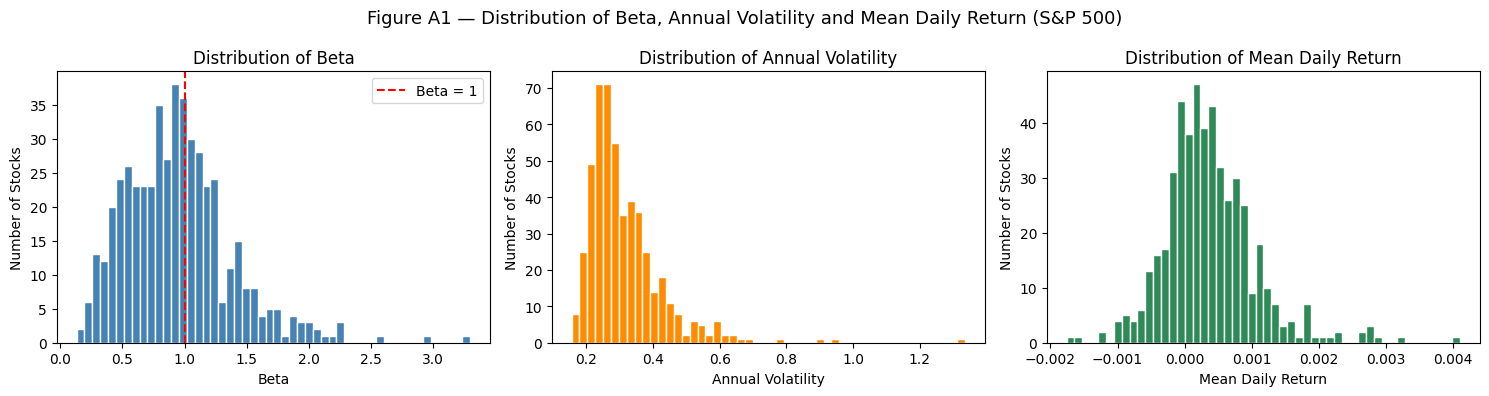

In [16]:
# Part 8: Visualisations — Metric Distributions and Risk Categories
# Figure A1: Distribution of the three key metrics across all S&P 500 stocks
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(metrics_df['Beta'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Beta')
axes[0].set_xlabel('Beta')
axes[0].set_ylabel('Number of Stocks')
axes[0].axvline(1.0, color='red', linestyle='--', label='Beta = 1')
axes[0].legend()

axes[1].hist(metrics_df['Annual Volatility'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Annual Volatility')
axes[1].set_xlabel('Annual Volatility')
axes[1].set_ylabel('Number of Stocks')

axes[2].hist(metrics_df['Mean Daily Return'], bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Distribution of Mean Daily Return')
axes[2].set_xlabel('Mean Daily Return')
axes[2].set_ylabel('Number of Stocks')

plt.suptitle('Figure A1 — Distribution of Beta, Annual Volatility and Mean Daily Return (S&P 500)', fontsize=13)
plt.tight_layout()
plt.show()

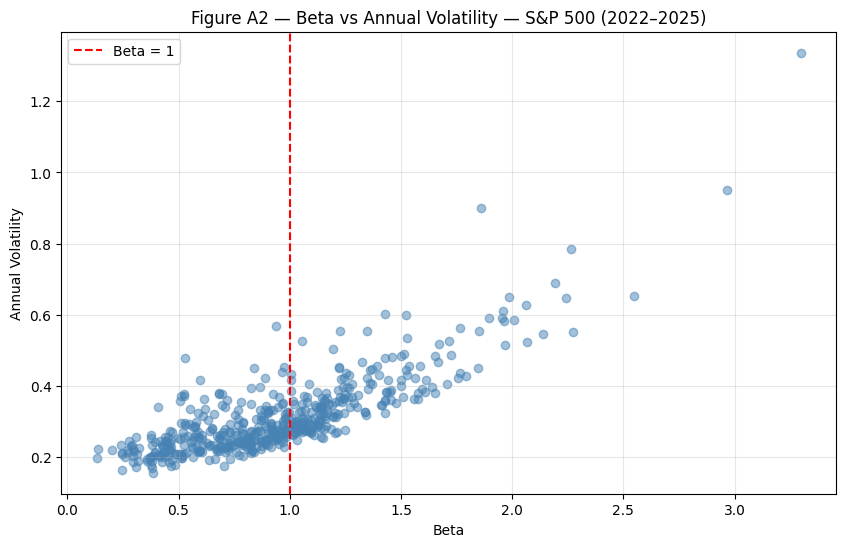

In [17]:
# Figure A2: Scatter plot — Beta vs Annual Volatility
# Confirms positive relationship: higher Beta stocks tend to have higher volatility
plt.figure(figsize=(10, 6))

plt.scatter(metrics_df['Beta'], metrics_df['Annual Volatility'], alpha=0.5, color='steelblue')
plt.axvline(1.0, color='red', linestyle='--', label='Beta = 1')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title('Figure A2 — Beta vs Annual Volatility — S&P 500 (2022–2025)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Risk Category Counts:
Risk Category
Moderate      195
Defensive     191
Aggressive    110
Name: count, dtype: int64


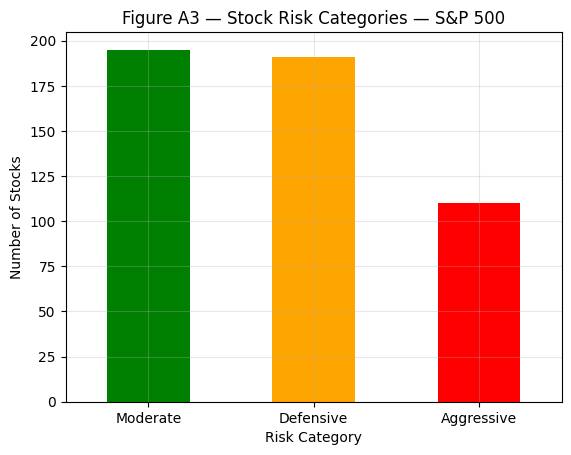

In [18]:
# Figure A3: Stock Risk Category Distribution based on Beta thresholds
# Defensive: Beta < 0.8 | Moderate: 0.8 <= Beta <= 1.2 | Aggressive: Beta > 1.2
def classify_risk(beta):
    if beta < 0.8:
        return 'Defensive'
    elif beta <= 1.2:
        return 'Moderate'
    else:
        return 'Aggressive'

metrics_df['Risk Category'] = metrics_df['Beta'].apply(classify_risk)

print('Risk Category Counts:')
print(metrics_df['Risk Category'].value_counts())

metrics_df['Risk Category'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Figure A3 — Stock Risk Categories — S&P 500')
plt.xlabel('Risk Category')
plt.ylabel('Number of Stocks')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
#TASK B — Stock Segmentation

In [20]:
# Install machine learning library
!pip install scikit-learn --quiet

In [21]:
# Import clustering algorithms, metrics and preprocessing tools
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

In [22]:
#Part 1: Agglomerative Clustering
# Scale the three metrics to ensure equal contribution to clustering
# StandardScaler: mean=0, std=1 for each feature
X = metrics_df[['Beta', 'Annual Volatility', 'Mean Daily Return']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Data ready for Agglomerative Clustering')
print('Shape:', X_scaled.shape)

# Figure B1: Scaled data preview
X_scaled_df = pd.DataFrame(X_scaled,
                            index=metrics_df.index,
                            columns=['Beta (Scaled)', 'Annual Volatility (Scaled)', 'Mean Daily Return (Scaled)'])
print('\nFigure B1 — Scaled Data (first 10 rows):')
X_scaled_df.head(10).round(4)

Data ready for Agglomerative Clustering
Shape: (496, 3)

Figure B1 — Scaled Data (first 10 rows):


,Beta (Scaled),Annual Volatility (Scaled),Mean Daily Return (Scaled)
Ticker,,,
A,0.1867,-0.1601,-0.5807
AAPL,0.6184,-0.3807,0.3020
ABBV,-1.4977,-0.8099,0.1409
ABNB,1.6755,1.3383,-0.4291
ABT,-0.6304,-0.8413,-0.8033
ACGL,-0.8704,-0.5148,1.0830
ACN,0.3501,-0.3860,-0.6107
ADBE,1.1695,0.5982,-0.5696
ADI,0.9167,0.0329,0.1142


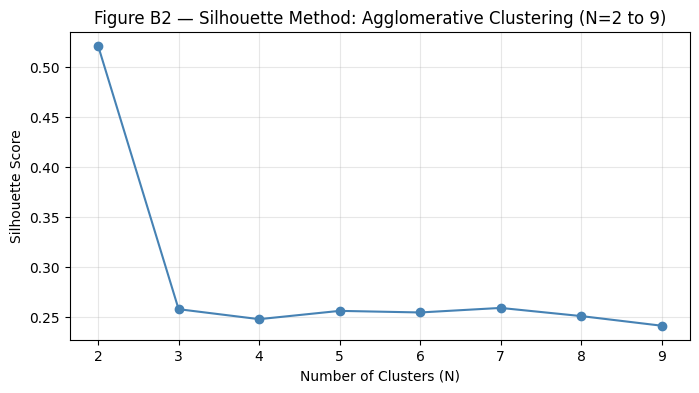

Best N by Silhouette: 2


,N Clusters,Silhouette Score
0,2,0.5211
1,3,0.2582
2,4,0.2482
3,5,0.2565
4,6,0.2549
5,7,0.2594
6,8,0.2513
7,9,0.2417


In [23]:
# Part 1b: Identify Optimal N — Silhouette Method
# Figure B2: Silhouette Method — identify optimal number of clusters N
# Higher silhouette score = better defined and separated clusters
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
silhouette_scores = []

for n in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n)
    labels = agglom.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, silhouette_scores, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (N)')
plt.ylabel('Silhouette Score')
plt.title('Figure B2 — Silhouette Method: Agglomerative Clustering (N=2 to 9)')
plt.xticks(range_n_clusters)
plt.grid(True, alpha=0.3)
plt.show()

silhouette_df = pd.DataFrame({
    'N Clusters': range_n_clusters,
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})
best_n = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
print(f'Best N by Silhouette: {best_n}')
silhouette_df

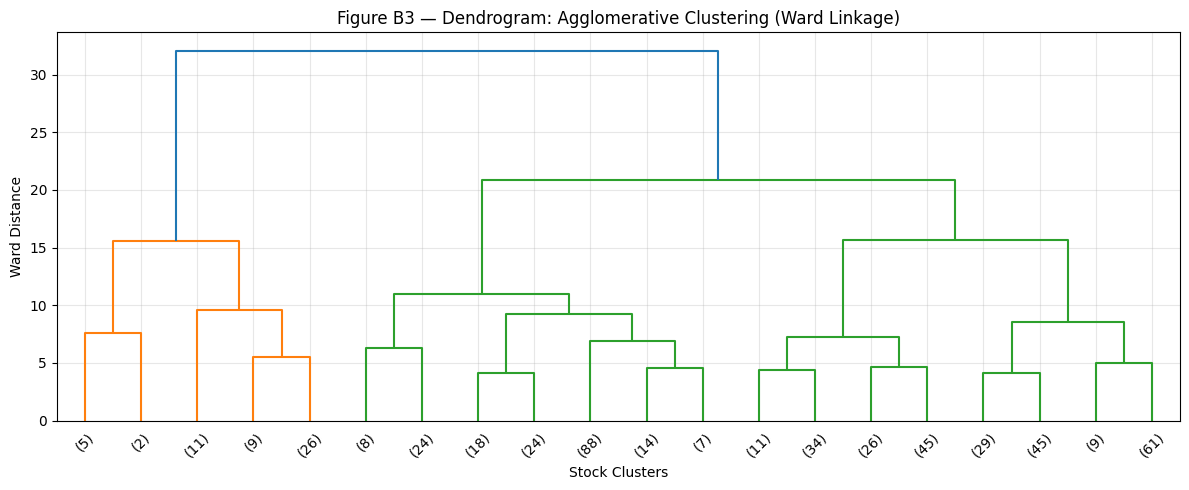

--- Last 10 Merge Distances (largest jump confirms optimal N) ---


,Step,Ward Distance
0,1,7.2195
1,2,7.6330
2,3,8.5326
3,4,9.2027
4,5,9.6142
5,6,10.9342
6,7,15.5324
7,8,15.6992
8,9,20.8289
9,10,32.0641


In [24]:
# Part 1c: Identify Optimal N — Dendrogram (Ward Linkage)
# Figure B3: Dendrogram — visually confirm optimal N
# Ward linkage minimises within-cluster variance at each merge step
# Largest jump in Ward Distance confirms optimal N
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10)
plt.title('Figure B3 — Dendrogram: Agglomerative Clustering (Ward Linkage)')
plt.xlabel('Stock Clusters')
plt.ylabel('Ward Distance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('--- Last 10 Merge Distances (largest jump confirms optimal N) ---')
last_merges = pd.DataFrame({
    'Step': range(1, 11),
    'Ward Distance': linkage_matrix[-10:, 2].round(4)
})
last_merges

In [25]:
#Part 1d: Implement Agglomerative Clustering (N=3)
# Figure B4: Agglomerative Clustering — implementation with N=3
# N=3 selected based on: Silhouette Score + Dendrogram analysis
optimal_n = 3

agglom = AgglomerativeClustering(n_clusters=optimal_n, linkage='ward')
cluster_labels = agglom.fit_predict(X_scaled)

metrics_df['Agglomerative Cluster'] = cluster_labels

print('--- Cluster Distribution ---')
print(metrics_df['Agglomerative Cluster'].value_counts().sort_index())

print('\nFigure B4 — Cluster Profiles (Mean Values):')
cluster_profiles = metrics_df.groupby('Agglomerative Cluster')[
    ['Beta', 'Annual Volatility', 'Mean Daily Return']
].mean().round(4)
cluster_profiles['Risk Profile'] = ['Defensive', 'Aggressive', 'Moderate']
cluster_profiles

--- Cluster Distribution ---
Agglomerative Cluster
0    260
1     53
2    183
Name: count, dtype: int64

Figure B4 — Cluster Profiles (Mean Values):


,Beta,Annual Volatility,Mean Daily Return,Risk Profile
Agglomerative Cluster,,,,
0,0.6733,0.2473,0.0003,Defensive
1,1.6579,0.5172,0.0015,Aggressive
2,1.1236,0.3485,0.0001,Moderate


In [26]:
# Detailed cluster summary: count, mean, min, max
print('--- Detailed Cluster Summary ---')
summary = metrics_df.groupby('Agglomerative Cluster')[
    ['Beta', 'Annual Volatility', 'Mean Daily Return']
].agg(['count', 'mean', 'min', 'max']).round(4)
summary

--- Detailed Cluster Summary ---


Beta                         Annual Volatility          \
                      count    mean     min     max             count    mean   
Agglomerative Cluster                                                           
0                       260  0.6733  0.1313  1.1858               260  0.2473   
1                        53  1.6579  0.8376  3.2985                53  0.5172   
2                       183  1.1236  0.5118  1.8500               183  0.3485   

                                      Mean Daily Return                  \
                          min     max             count    mean     min   
Agglomerative Cluster                                                     
0                      0.1556  0.3793               260  0.0003 -0.0013   
1                      0.3510  1.3366                53  0.0015 -0.0000   
2                      0.2328  0.6016               183  0.0001 -0.0018   

                               
                          max  
Agglomerative Cluster          
0                      0.0019  
1                      0.0041  
2                      0.0009

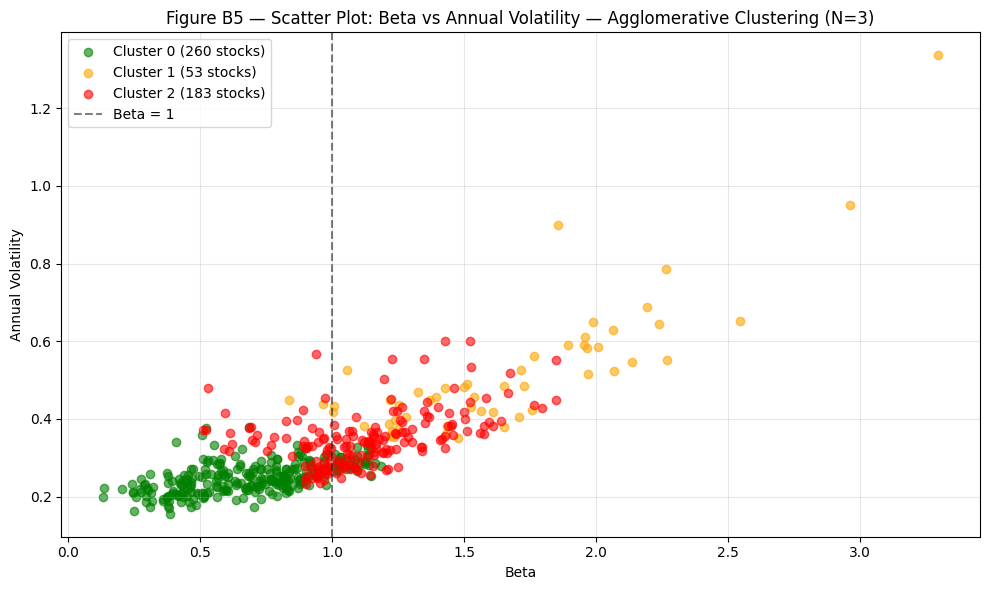

In [27]:
# Figure B5: Scatter plot — Beta vs Annual Volatility by Agglomerative Cluster
plt.figure(figsize=(10, 6))
colors = ['green', 'orange', 'red']

for i in range(optimal_n):
    mask = metrics_df['Agglomerative Cluster'] == i
    plt.scatter(
        metrics_df[mask]['Beta'],
        metrics_df[mask]['Annual Volatility'],
        label=f'Cluster {i} ({mask.sum()} stocks)',
        alpha=0.6,
        color=colors[i]
    )

plt.axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Beta = 1')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title('Figure B5 — Scatter Plot: Beta vs Annual Volatility — Agglomerative Clustering (N=3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

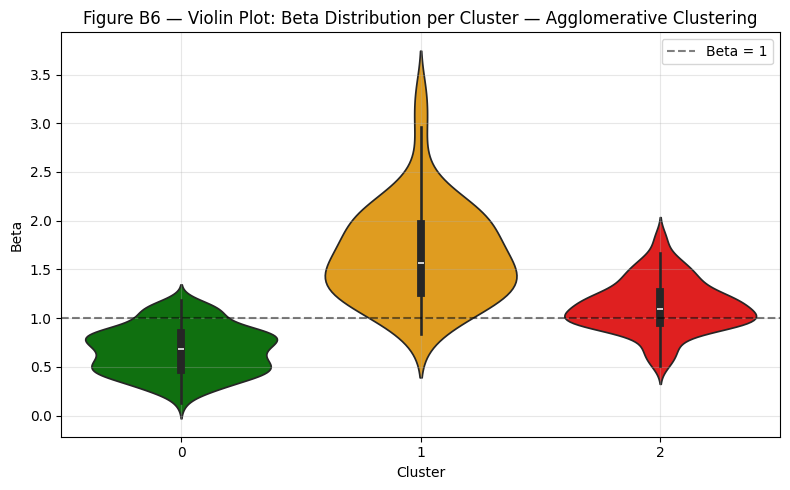

In [28]:
# Figure B6: Violin plot — Beta distribution per Agglomerative Cluster
plt.figure(figsize=(8, 5))
sns.violinplot(x='Agglomerative Cluster', y='Beta', data=metrics_df,
               palette=['green', 'orange', 'red'],
               hue='Agglomerative Cluster', legend=False)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Beta = 1')
plt.title('Figure B6 — Violin Plot: Beta Distribution per Cluster — Agglomerative Clustering')
plt.xlabel('Cluster')
plt.ylabel('Beta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

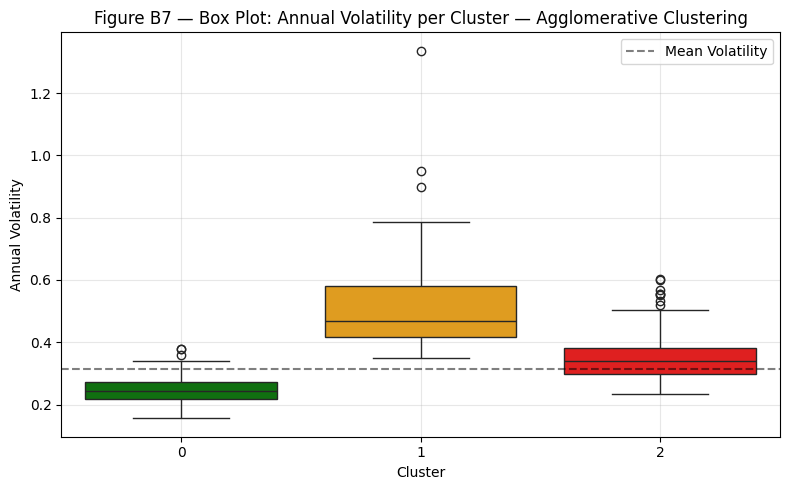

In [29]:
# Figure B7: Box plot — Annual Volatility distribution per Agglomerative Cluster
plt.figure(figsize=(8, 5))
sns.boxplot(x='Agglomerative Cluster', y='Annual Volatility',
            data=metrics_df, palette=['green', 'orange', 'red'],
            hue='Agglomerative Cluster', legend=False)
plt.axhline(metrics_df['Annual Volatility'].mean(),
            color='black', linestyle='--', alpha=0.5, label='Mean Volatility')
plt.title('Figure B7 — Box Plot: Annual Volatility per Cluster — Agglomerative Clustering')
plt.xlabel('Cluster')
plt.ylabel('Annual Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
#Part 2: K-Means Clustering

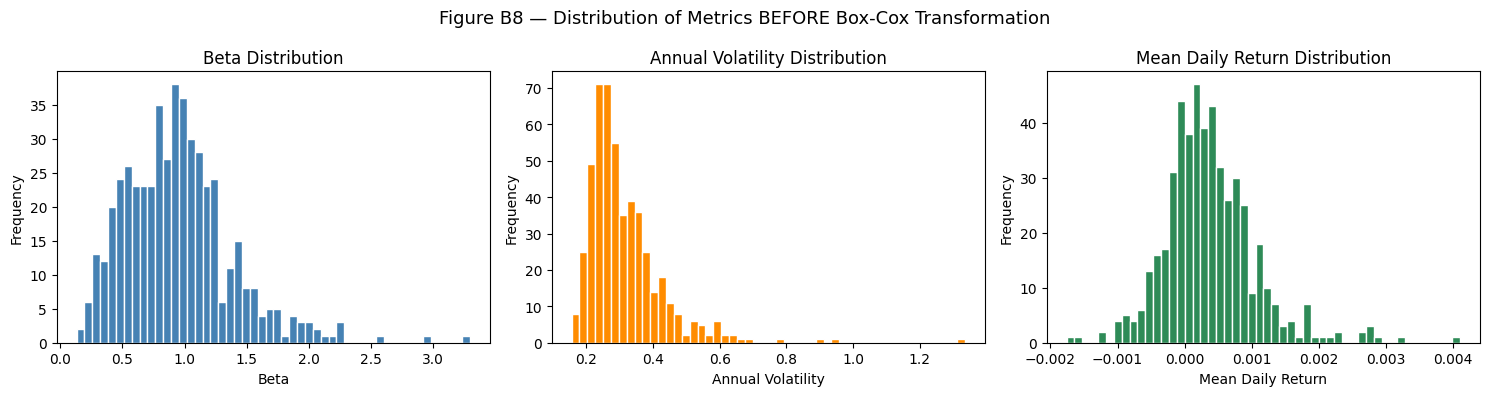

In [31]:
# Figure B8: Histograms BEFORE Box-Cox transformation
# K-Means is sensitive to skewed distributions (Euclidean distance affected by outliers)
# Must check and correct skewness before applying K-Means
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(metrics_df['Beta'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Beta Distribution')
axes[0].set_xlabel('Beta')
axes[0].set_ylabel('Frequency')

axes[1].hist(metrics_df['Annual Volatility'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Annual Volatility Distribution')
axes[1].set_xlabel('Annual Volatility')
axes[1].set_ylabel('Frequency')

axes[2].hist(metrics_df['Mean Daily Return'], bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Mean Daily Return Distribution')
axes[2].set_xlabel('Mean Daily Return')
axes[2].set_ylabel('Frequency')

plt.suptitle('Figure B8 — Distribution of Metrics BEFORE Box-Cox Transformation', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
#Part 2b: Remove Skewness — Apply Box-Cox Transformation

In [33]:
# Apply Box-Cox transformation to Beta and Annual Volatility to remove right skewness
# Mean Daily Return is approximately normal — no transformation needed
# Box-Cox requires strictly positive values — dynamic shift applied
shift_beta = abs(metrics_df['Beta'].min()) + 0.001
shift_vol = abs(metrics_df['Annual Volatility'].min()) + 0.001

beta_transformed, _ = boxcox(metrics_df['Beta'] + shift_beta)
volatility_transformed, _ = boxcox(metrics_df['Annual Volatility'] + shift_vol)

metrics_transformed = metrics_df.copy()
metrics_transformed['Beta'] = beta_transformed
metrics_transformed['Annual Volatility'] = volatility_transformed

print('Box-Cox transformation applied successfully')
print('Beta and Annual Volatility transformed | Mean Daily Return unchanged')

Box-Cox transformation applied successfully
Beta and Annual Volatility transformed | Mean Daily Return unchanged


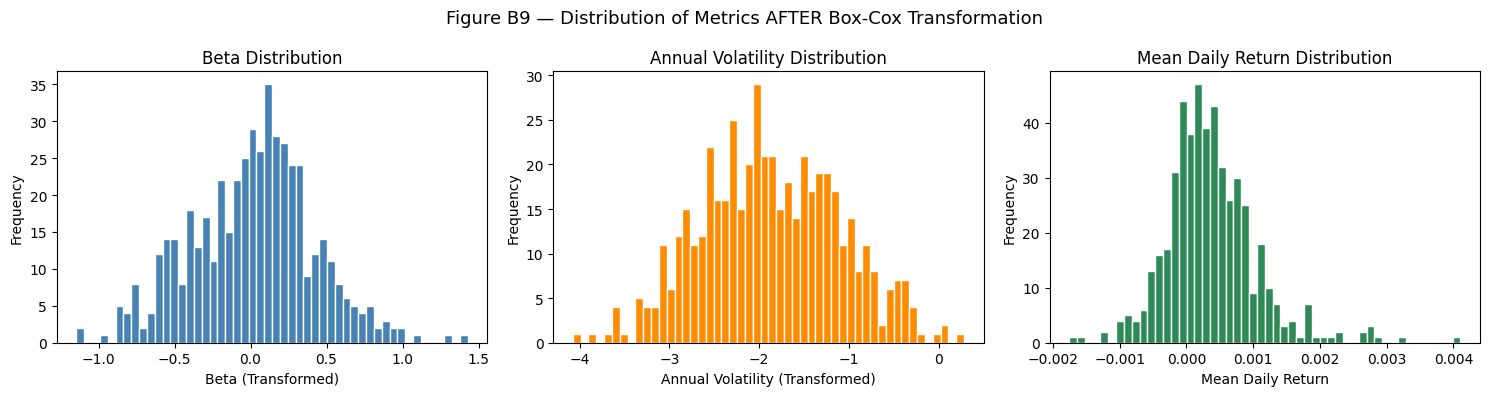

In [34]:
# Figure B9: Histograms AFTER Box-Cox transformation — verify skewness removed
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(metrics_transformed['Beta'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Beta Distribution')
axes[0].set_xlabel('Beta (Transformed)')
axes[0].set_ylabel('Frequency')

axes[1].hist(metrics_transformed['Annual Volatility'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Annual Volatility Distribution')
axes[1].set_xlabel('Annual Volatility (Transformed)')
axes[1].set_ylabel('Frequency')

axes[2].hist(metrics_transformed['Mean Daily Return'], bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Mean Daily Return Distribution')
axes[2].set_xlabel('Mean Daily Return')
axes[2].set_ylabel('Frequency')

plt.suptitle('Figure B9 — Distribution of Metrics AFTER Box-Cox Transformation', fontsize=13)
plt.tight_layout()
plt.show()

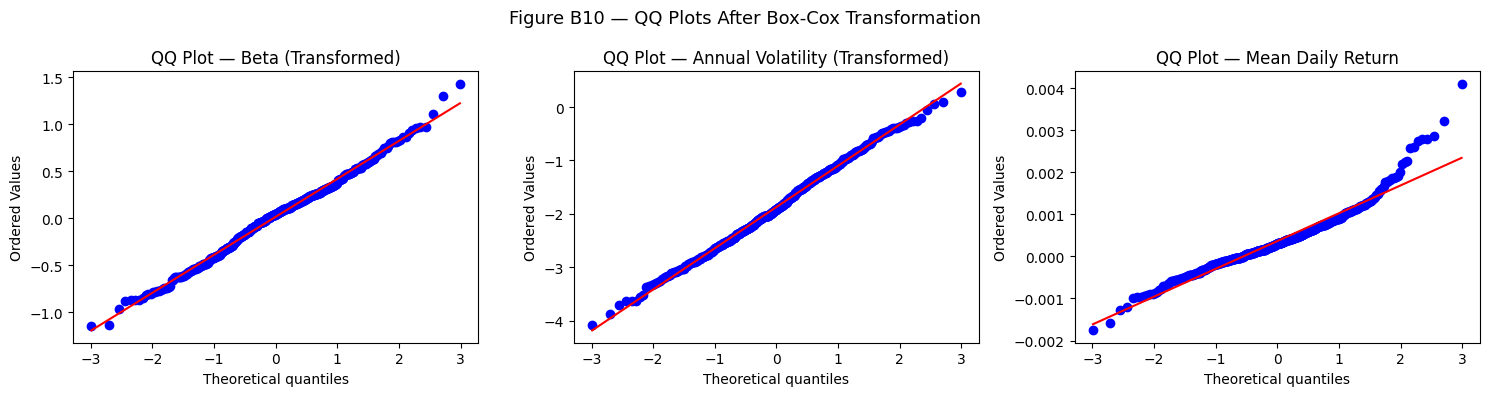

In [35]:
# Figure B10: QQ Plots — formally confirm normality after Box-Cox
# Points close to the red line indicate normal distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

stats.probplot(metrics_transformed['Beta'], plot=axes[0])
axes[0].set_title('QQ Plot — Beta (Transformed)')
axes[0].get_lines()[1].set_color('red')

stats.probplot(metrics_transformed['Annual Volatility'], plot=axes[1])
axes[1].set_title('QQ Plot — Annual Volatility (Transformed)')
axes[1].get_lines()[1].set_color('red')

stats.probplot(metrics_transformed['Mean Daily Return'], plot=axes[2])
axes[2].set_title('QQ Plot — Mean Daily Return')
axes[2].get_lines()[1].set_color('red')

plt.suptitle('Figure B10 — QQ Plots After Box-Cox Transformation', fontsize=13)
plt.tight_layout()
plt.show()

In [36]:
#Part 2c: Scale Transformed Data (StandardScaler for K-Means)

In [37]:
# Scale transformed metrics before applying K-Means
# StandardScaler applied AFTER Box-Cox transformation
X_kmeans = metrics_transformed[['Beta', 'Annual Volatility', 'Mean Daily Return']]

scaler_kmeans = StandardScaler()
X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans)

print('Data ready for K-Means clustering')
print('Shape:', X_kmeans_scaled.shape)

X_kmeans_scaled_df = pd.DataFrame(X_kmeans_scaled,
                                   index=metrics_df.index,
                                   columns=['Beta (Scaled)', 'Annual Volatility (Scaled)', 'Mean Daily Return (Scaled)'])
X_kmeans_scaled_df.head(10).round(4)

Data ready for K-Means clustering
Shape: (496, 3)


,Beta (Scaled),Annual Volatility (Scaled),Mean Daily Return (Scaled)
Ticker,,,
A,0.3352,0.0967,-0.5807
AAPL,0.7260,-0.2411,0.3020
ABBV,-1.9373,-1.0896,0.1409
ABNB,1.5321,1.4514,-0.4291
ABT,-0.5612,-1.1644,-0.8033
ACGL,-0.8817,-0.4756,1.0830
ACN,0.4885,-0.2498,-0.6107
ADBE,1.1687,0.9338,-0.5696
ADI,0.9725,0.3514,0.1142


In [38]:
#Part 2d: Identify Optimal K — Silhouette Method (K-Means)

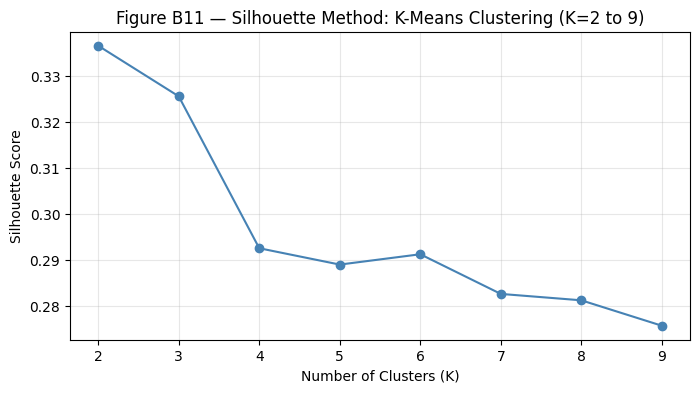

Best K by Silhouette: 2


,K Clusters,Silhouette Score
0,2,0.3365
1,3,0.3255
2,4,0.2925
3,5,0.2890
4,6,0.2912
5,7,0.2826
6,8,0.2812
7,9,0.2757


In [39]:
# Figure B11: Silhouette Method — identify optimal K for K-Means
range_k = [2, 3, 4, 5, 6, 7, 8, 9]
silhouette_scores_kmeans = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans_scaled)
    labels = kmeans.labels_
    silhouette_scores_kmeans.append(silhouette_score(X_kmeans_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(range_k, silhouette_scores_kmeans, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Figure B11 — Silhouette Method: K-Means Clustering (K=2 to 9)')
plt.xticks(range_k)
plt.grid(True, alpha=0.3)
plt.show()

silhouette_kmeans_df = pd.DataFrame({
    'K Clusters': range_k,
    'Silhouette Score': [round(s, 4) for s in silhouette_scores_kmeans]
})
best_k = range_k[silhouette_scores_kmeans.index(max(silhouette_scores_kmeans))]
print(f'Best K by Silhouette: {best_k}')
silhouette_kmeans_df

In [40]:
#Part 2e: Identify Optimal K — Elbow Method

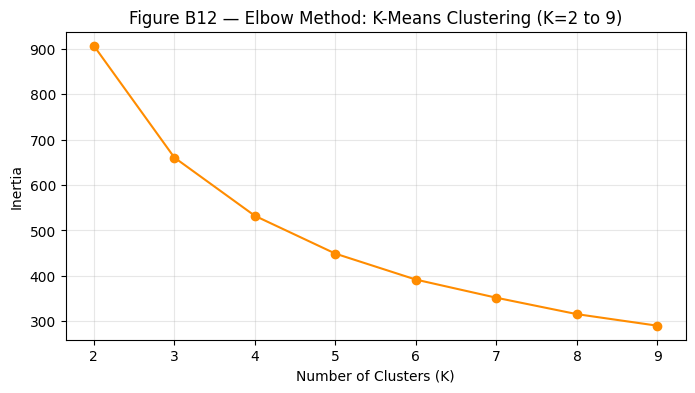

,K Clusters,Inertia
0,2,906.7615
1,3,660.5266
2,4,532.2104
3,5,448.9107
4,6,391.7408
5,7,351.7881
6,8,315.6622
7,9,290.1811


In [41]:
# Figure B12: Elbow Method — further confirm optimal K
# Plot inertia (sum of squared distances to centroid) vs number of clusters
inertia = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range_k, inertia, marker='o', color='darkorange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Figure B12 — Elbow Method: K-Means Clustering (K=2 to 9)')
plt.xticks(range_k)
plt.grid(True, alpha=0.3)
plt.show()

elbow_df = pd.DataFrame({
    'K Clusters': range_k,
    'Inertia': [round(i, 4) for i in inertia]
})
elbow_df

In [42]:
#Part 2f: Implement K-Means Clustering (K=3)

In [43]:
# Figure B13: K-Means Clustering — implementation with K=3
# K=3 selected based on:
# 1. Elbow Method: clear elbow at K=3
# 2. Silhouette Score: K=3 (0.3248) comparable to K=2 (0.3337) — negligible difference of 0.009
# 3. Business logic: three distinct investor risk profiles (Defensive / Moderate / Aggressive)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_kmeans_scaled)

metrics_df['KMeans Cluster'] = kmeans_labels

print('--- Cluster Distribution ---')
print(metrics_df['KMeans Cluster'].value_counts().sort_index())

print('\nFigure B13 — K-Means Cluster Profiles (Mean Values):')
cluster_profiles_kmeans = metrics_df.groupby('KMeans Cluster')[
    ['Beta', 'Annual Volatility', 'Mean Daily Return']
].mean().round(4)
cluster_profiles_kmeans['Risk Profile'] = ['Defensive', 'Aggressive', 'Moderate']
cluster_profiles_kmeans

--- Cluster Distribution ---
KMeans Cluster
0    238
1     74
2    184
Name: count, dtype: int64

Figure B13 — K-Means Cluster Profiles (Mean Values):


,Beta,Annual Volatility,Mean Daily Return,Risk Profile
KMeans Cluster,,,,
0,1.0476,0.3317,0.0001,Defensive
1,1.5254,0.4669,0.0014,Aggressive
2,0.5779,0.2283,0.0003,Moderate


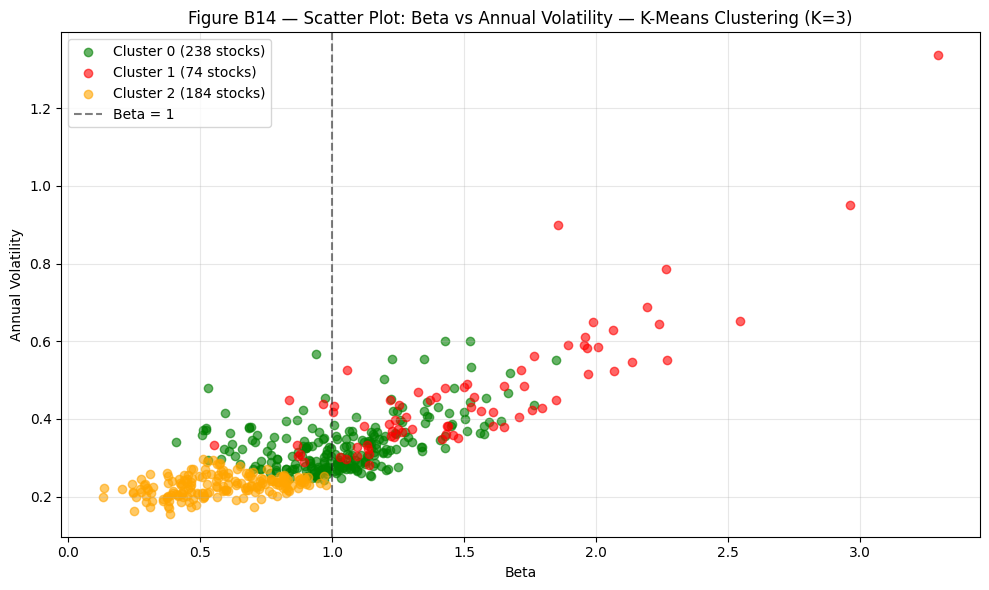

In [44]:
# Figure B14: Scatter plot — Beta vs Annual Volatility by K-Means Cluster
plt.figure(figsize=(10, 6))
colors_k = ['green', 'red', 'orange']

for i in range(optimal_k):
    mask = metrics_df['KMeans Cluster'] == i
    plt.scatter(
        metrics_df[mask]['Beta'],
        metrics_df[mask]['Annual Volatility'],
        label=f'Cluster {i} ({mask.sum()} stocks)',
        alpha=0.6,
        color=colors_k[i]
    )

plt.axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Beta = 1')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title('Figure B14 — Scatter Plot: Beta vs Annual Volatility — K-Means Clustering (K=3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

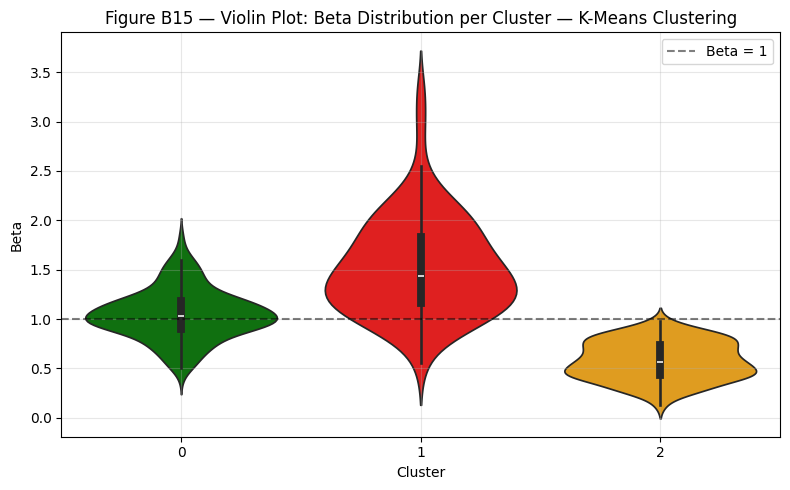

In [45]:
# Figure B15: Violin plot — Beta distribution per K-Means Cluster
plt.figure(figsize=(8, 5))
sns.violinplot(x='KMeans Cluster', y='Beta', data=metrics_df,
               palette=['green', 'red', 'orange'],
               hue='KMeans Cluster', legend=False)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Beta = 1')
plt.title('Figure B15 — Violin Plot: Beta Distribution per Cluster — K-Means Clustering')
plt.xlabel('Cluster')
plt.ylabel('Beta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

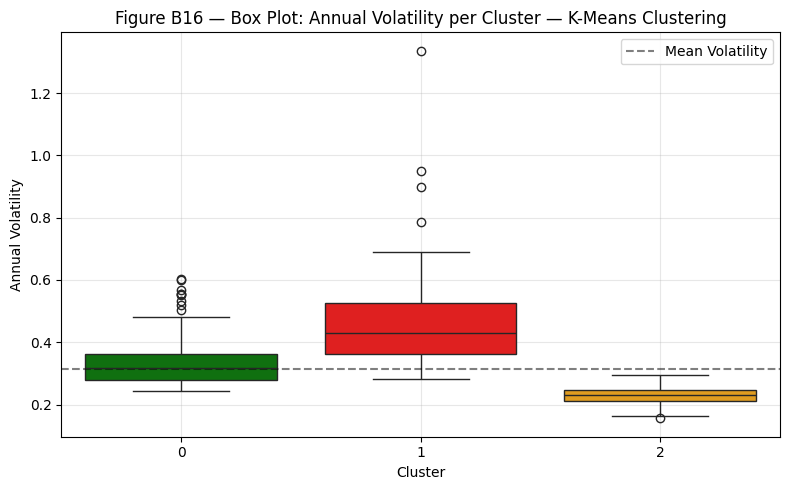

In [46]:
# Figure B16: Box plot — Annual Volatility distribution per K-Means Cluster
plt.figure(figsize=(8, 5))
sns.boxplot(x='KMeans Cluster', y='Annual Volatility',
            data=metrics_df, palette=['green', 'red', 'orange'],
            hue='KMeans Cluster', legend=False)
plt.axhline(metrics_df['Annual Volatility'].mean(),
            color='black', linestyle='--', alpha=0.5, label='Mean Volatility')
plt.title('Figure B16 — Box Plot: Annual Volatility per Cluster — K-Means Clustering')
plt.xlabel('Cluster')
plt.ylabel('Annual Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Figure B17: Sample stocks per cluster — top 5 by highest Beta
# Business interpretation of each risk profile
print('Figure B17 — Sample Stocks per Cluster (Top 5 Highest Beta):')
for i in range(optimal_k):
    cluster_stocks = metrics_df[metrics_df['KMeans Cluster'] == i][
        ['Beta', 'Annual Volatility', 'Mean Daily Return']
    ].sort_values('Beta', ascending=False).head(5)
    risk = cluster_profiles_kmeans.loc[i, 'Risk Profile']
    print(f'\nCluster {i} ({risk}) — Top 5 stocks by Beta:')
    print(cluster_stocks.to_string())

Figure B17 — Sample Stocks per Cluster (Top 5 Highest Beta):

Cluster 0 (Defensive) — Top 5 stocks by Beta:
          Beta  Annual Volatility  Mean Daily Return
Ticker                                              
GNRC    1.8500           0.552753          -0.000451
TER     1.7663           0.436869           0.000020
ALGN    1.6728           0.518704          -0.000966
ABNB    1.6685           0.466325           0.000074
MCHP    1.6394           0.395668          -0.000257

Cluster 1 (Aggressive) — Top 5 stocks by Beta:
          Beta  Annual Volatility  Mean Daily Return
Ticker                                              
CVNA    3.2985           1.336597           0.003219
COIN    2.9649           0.950688           0.001768
XYZ     2.5482           0.651659          -0.000034
NVDA    2.2714           0.550865           0.002586
APP     2.2649           0.785763           0.002802

Cluster 2 (Moderate) — Top 5 stocks by Beta:
          Beta  Annual Volatility  Mean Daily Return
Tic

In [48]:
#TASK C — Review Results and CRM as a Driver for Sustainability

In [49]:
# Part 1, Part 2: are answered in the group report.

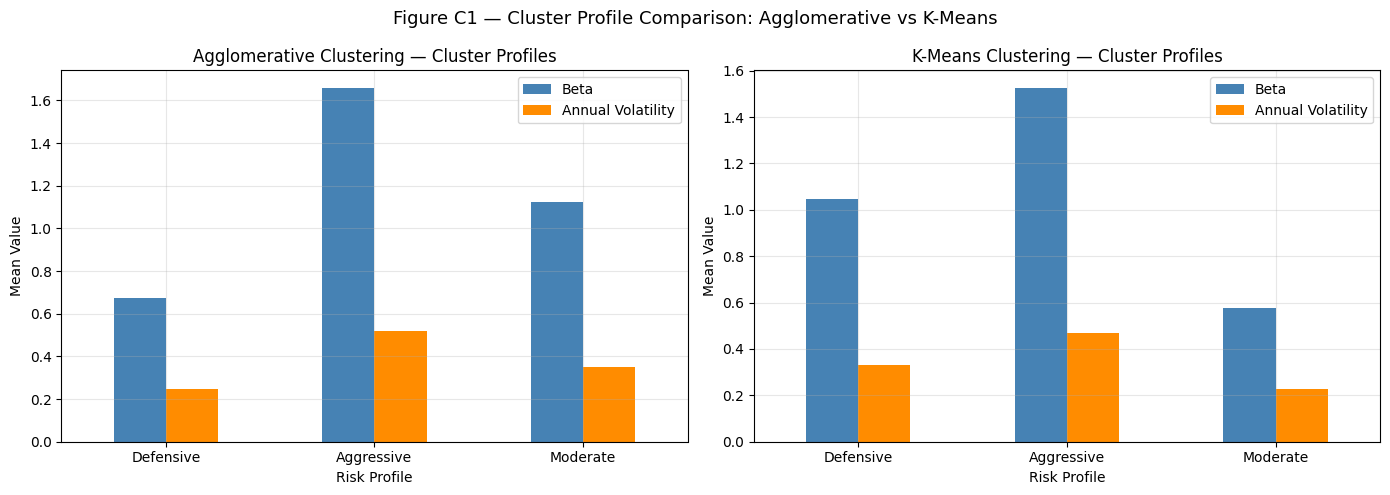

In [50]:
#Figures to support Task C
# Figure C1: Side-by-side cluster profile comparison — Agglomerative vs K-Means
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Agglomerative profiles
agg_profiles = metrics_df.groupby('Agglomerative Cluster')[['Beta', 'Annual Volatility', 'Mean Daily Return']].mean()
agg_profiles.index = ['Defensive', 'Aggressive', 'Moderate']
agg_profiles[['Beta', 'Annual Volatility']].plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('Agglomerative Clustering — Cluster Profiles')
axes[0].set_xlabel('Risk Profile')
axes[0].set_ylabel('Mean Value')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# K-Means profiles
km_profiles = metrics_df.groupby('KMeans Cluster')[['Beta', 'Annual Volatility', 'Mean Daily Return']].mean()
km_profiles.index = ['Defensive', 'Aggressive', 'Moderate']
km_profiles[['Beta', 'Annual Volatility']].plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'])
axes[1].set_title('K-Means Clustering — Cluster Profiles')
axes[1].set_xlabel('Risk Profile')
axes[1].set_ylabel('Mean Value')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure C1 — Cluster Profile Comparison: Agglomerative vs K-Means', fontsize=13)
plt.tight_layout()
plt.show()

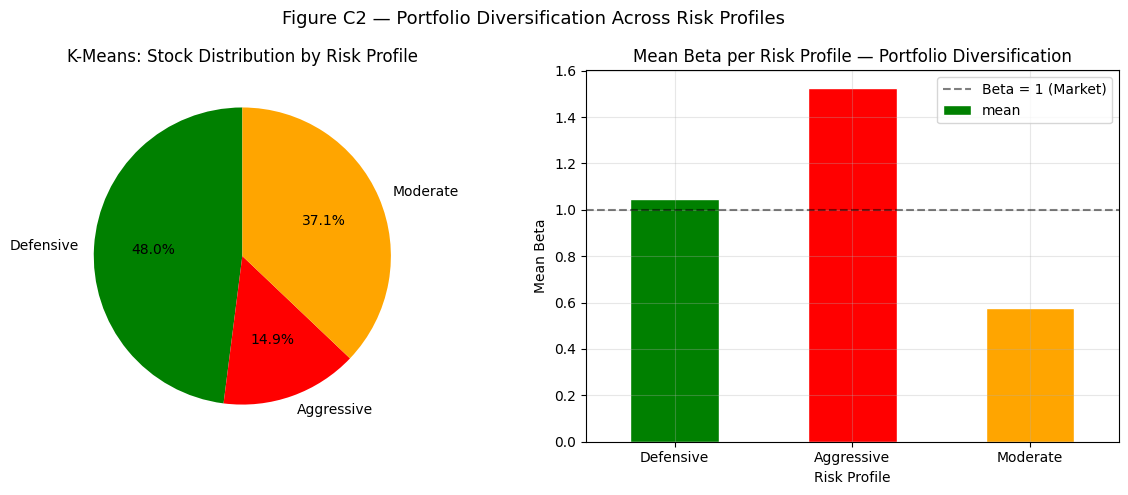

In [51]:
# Figure C2: Portfolio diversification — stock count and risk spread across clusters
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means cluster sizes
km_counts = metrics_df['KMeans Cluster'].value_counts().sort_index()
km_labels = ['Defensive', 'Aggressive', 'Moderate']
colors_pie = ['green', 'red', 'orange']
axes[0].pie(km_counts, labels=km_labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[0].set_title('K-Means: Stock Distribution by Risk Profile')

# Beta range per cluster (shows diversification potential)
beta_ranges = metrics_df.groupby('KMeans Cluster')['Beta'].agg(['min', 'max', 'mean'])
beta_ranges.index = ['Defensive', 'Aggressive', 'Moderate']
beta_ranges['mean'].plot(kind='bar', ax=axes[1], color=['green', 'red', 'orange'], edgecolor='white')
axes[1].set_title('Mean Beta per Risk Profile — Portfolio Diversification')
axes[1].set_xlabel('Risk Profile')
axes[1].set_ylabel('Mean Beta')
axes[1].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Beta = 1 (Market)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure C2 — Portfolio Diversification Across Risk Profiles', fontsize=13)
plt.tight_layout()
plt.show()